# Exploratory Data Analysis

**Project:** Energy Forecasting — Household Electricity Consumption (Enel × LUISS).

**Dataset:** UCI *Individual Household Electric Power Consumption* — a single household in Sceaux (Paris area), France. 2,075,259 minute-level measurements between **2006-12-16** and **2010-11-26** (~47 months).

**Goal of this notebook:** establish, with evidence, the structural facts about the time series that will drive every later decision — frequency, target choice, missing-value policy, seasonality regime, autocorrelation structure, segment behavior, and the EDA → modeling handoff.

All data loading, preprocessing, and feature engineering here go through the project's installable package (`energy_forecasting`). The configuration in [`conf/base.yaml`](../conf/base.yaml) is the single source of truth — *no parameter is duplicated in this notebook*.

---

## 1 · Setup

Load the package, pull the pinned configuration, fix the random seed for reproducibility, and configure logging. The single import to remember: everything operational lives under [`src/energy_forecasting/`](../src/energy_forecasting/).

In [1]:
# =============================================================
# 1.1  IMPORTS AND CONFIGURATION
# =============================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from energy_forecasting.config import DEFAULT_CONFIG_PATH, ForecastConfig
from energy_forecasting.data import load_raw, validate_raw
from energy_forecasting.preprocessing import summarize_missing_gaps
from energy_forecasting.utils import set_global_seed

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

cfg = ForecastConfig.from_yaml(DEFAULT_CONFIG_PATH)
set_global_seed(cfg.reproducibility.seed)

print(f"Package config hash : {cfg.content_hash()[:12]}")
print(f"Target column       : {cfg.target.column}")
print(f"Target frequency    : {cfg.target.frequency}")
print(f"Forecast horizon    : {cfg.target.horizon_hours} hours")
print(f"Strict leakage-safe : {cfg.features.strict_leakage_safe}")
print(f"Random seed         : {cfg.reproducibility.seed}")

Package config hash : 050755a0a6eb
Target column       : Global_active_power
Target frequency    : 1h
Forecast horizon    : 24 hours
Strict leakage-safe : True
Random seed         : 42


## 2 · Load and Validate Raw Data

The raw UCI text file lives at [`data/raw/data.txt`](../data/raw/data.txt). It is loaded through [`energy_forecasting.data.load_raw`](../src/energy_forecasting/data/loader.py) which parses the semicolon-delimited file, joins the separate `Date` / `Time` columns into a `DatetimeIndex`, and coerces the `?` missing-value sentinel to `NaN`.

After loading we run [`validate_raw`](../src/energy_forecasting/data/validator.py) against the configured ForecastConfig — it checks structural integrity (index sorted, no duplicates), schema (expected columns present, correct dtypes), physical plausibility (no negative power, voltages in 100–300 V), and sufficiency for the configured rolling-origin CV scheme.

In [2]:
# =============================================================
# 2.1  LOAD THE RAW DATASET
# =============================================================
raw_path = Path("..") / "data" / "raw" / "data.txt"
df_raw = load_raw(raw_path)

print(f"Shape           : {df_raw.shape}")
print(f"Memory          : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Date range      : {df_raw.index.min()}  →  {df_raw.index.max()}")
print(f"Inferred freq   : {pd.infer_freq(df_raw.index[:50])}")
print(f"Months covered  : {(df_raw.index.max() - df_raw.index.min()).days / 30.44:.1f}")

2026-05-13 10:56:53 | INFO     | energy_forecasting.data.loader:load_raw:71 | Loading raw dataset from ..\data\raw\data.txt


2026-05-13 10:57:13 | INFO     | energy_forecasting.data.loader:load_raw:117 | Loaded 2,075,259 rows × 7 columns, range 2006-12-16 17:24:00 → 2010-11-26 21:02:00


Shape           : (2075259, 7)
Memory          : 132.8 MB
Date range      : 2006-12-16 17:24:00  →  2010-11-26 21:02:00
Inferred freq   : min
Months covered  : 47.3


In [3]:
df_raw.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# =============================================================
# 2.2  CONFIG-AWARE QUALITY VALIDATION
# =============================================================
report = validate_raw(df_raw, config=cfg, raise_on_fail=False)

print(f"Passed              : {report.passed}")
print(f"Total rows          : {report.n_rows:,}")
print(f"Rows with any NaN   : {report.n_missing_rows:,}  ({report.n_missing_rows / report.n_rows * 100:.2f}%)")
print(f"Date range          : {report.duration_index[0]}  →  {report.duration_index[1]}")
if report.issues:
    print("\nIssues:")
    for i in report.issues:
        print(f"  • {i}")

2026-05-13 10:57:14 | INFO     | energy_forecasting.data.validator:validate_raw:180 | Validation passed: 2,075,259 rows, 25,979 with missing values, range 2006-12-16 17:24:00 → 2010-11-26 21:02:00


Passed              : True
Total rows          : 2,075,259
Rows with any NaN   : 25,979  (1.25%)
Date range          : 2006-12-16 17:24:00  →  2010-11-26 21:02:00


## 3 · Per-Column Data Audit

A compact one-glance table giving — for every measurement column — its dtype, percentage of missing values, and number of unique values. Useful for spotting columns that are nominally numeric but practically categorical (low unique count) and for confirming that every column shares the same missing-value rate (a strong signal about whether missingness is row-level or column-level).

In [5]:
# =============================================================
# 3.1  PER-COLUMN AUDIT TABLE
# =============================================================
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_pct": (df_raw.isna().mean() * 100).round(3),
    "n_unique": df_raw.nunique(dropna=True),
    "min": df_raw.min(numeric_only=True).round(3),
    "median": df_raw.median(numeric_only=True).round(3),
    "max": df_raw.max(numeric_only=True).round(3),
})
audit

,dtype,missing_pct,n_unique,min,median,max
Global_active_power,float64,1.252,4186,0.076,0.602,11.122
Global_reactive_power,float64,1.252,532,0.000,0.100,1.390
Voltage,float64,1.252,2837,223.200,241.010,254.150
Global_intensity,float64,1.252,221,0.200,2.600,48.400
Sub_metering_1,float64,1.252,88,0.000,0.000,88.000
Sub_metering_2,float64,1.252,81,0.000,0.000,80.000
Sub_metering_3,float64,1.252,32,0.000,1.000,31.000


## 4 · Missingness Structure Deep-Dive

Before any modeling we need to understand *why* values are missing and *how* they're distributed in time. The audit table in §3 will already hint at the answer (every column is missing in lockstep — same percentage to three decimal places), but we need to confirm it formally and characterize the missing-gap geometry.

We answer three questions:

- **4.1** Are missing rows shared across columns, or column-specific?
- **4.2** When do missing rows occur — uniformly, or clustered in time?
- **4.3** Are gaps short isolated blips or long structural outages?

The answers determine our missing-value policy ([`apply_missing_value_policy`](../src/energy_forecasting/preprocessing/missing.py)), which uses different treatments for short and long gaps.

### 4.1 Are missing rows shared across columns?

If every column is missing at exactly the same rows, missingness is a **row-level** phenomenon — the data acquisition system failed to record those timestamps at all. If columns disagree, missingness is **column-level** — some sensors failed independently.

In [6]:
# =============================================================
# 4.1  ROW-LEVEL vs COLUMN-LEVEL MISSINGNESS
# =============================================================
missing_mask = df_raw.isna()
row_missing_count = missing_mask.sum(axis=1)
rows_with_any_missing = int((row_missing_count > 0).sum())
rows_with_all_missing = int((row_missing_count == df_raw.shape[1]).sum())

# All-columns-share-pattern check: compare each column's NA pattern to column 0's.
ref = missing_mask.iloc[:, 0]
all_share = bool(missing_mask.apply(lambda col: col.equals(ref)).all())

print(f"Total rows                          : {len(df_raw):,}")
print(f"Rows with ≥1 missing value          : {rows_with_any_missing:,} ({rows_with_any_missing / len(df_raw) * 100:.2f}%)")
print(f"Rows where ALL columns are missing  : {rows_with_all_missing:,}")
print(f"All columns share the same NA mask  : {all_share}")

Total rows                          : 2,075,259
Rows with ≥1 missing value          : 25,979 (1.25%)
Rows where ALL columns are missing  : 25,979
All columns share the same NA mask  : True


### 4.2 When do missing rows occur?

Look at the missing-row rate by hour of day, by day of week, and by calendar month. If missingness is uniform across all three, the process is *missing completely at random* (MCAR) and any reasonable imputation works. If missingness clusters in time, we have **non-MCAR** missingness, which the imputation strategy must respect.

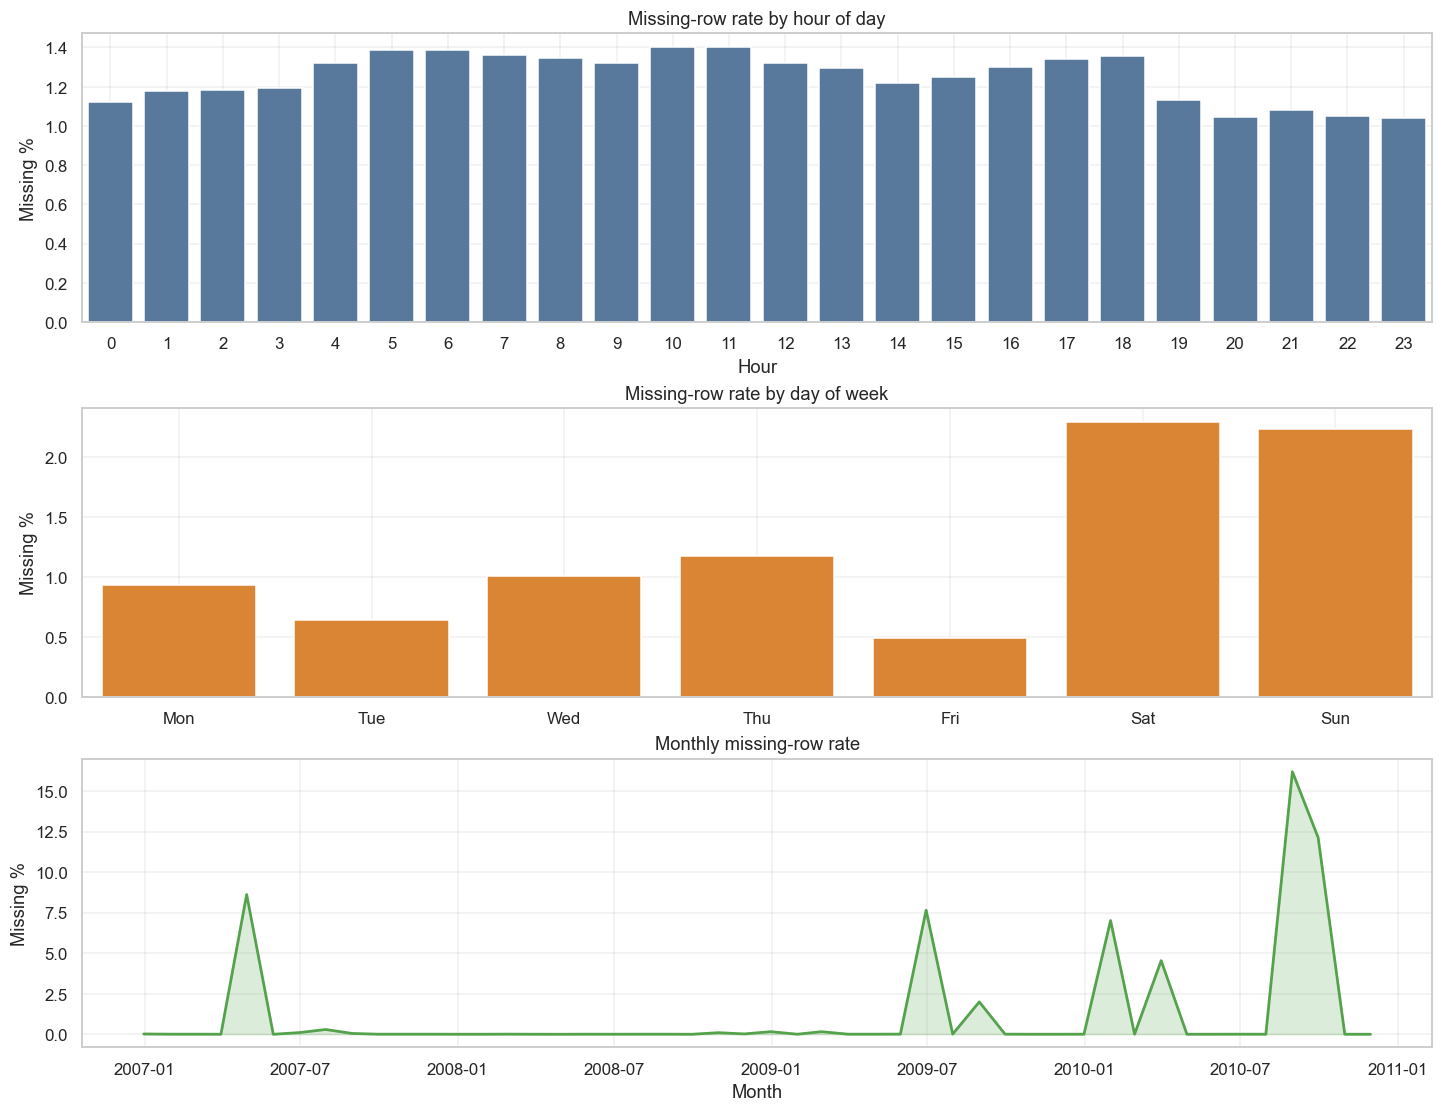

Top 5 hours by missing %:
datetime
11    1.401804
10    1.401804
6     1.389082
5     1.387925
7     1.360167
Name: is_missing, dtype: float64

Month with highest missing %:
2010-08-31 00:00:00 (16.19%)


In [7]:
# =============================================================
# 4.2  TEMPORAL DISTRIBUTION OF MISSINGNESS
# =============================================================
missing_any = df_raw.isna().any(axis=1)
missing_df = missing_any.to_frame("is_missing")

by_hour    = missing_df.groupby(missing_df.index.hour)["is_missing"].mean() * 100
by_dow     = missing_df.groupby(missing_df.index.dayofweek)["is_missing"].mean() * 100
by_month   = missing_df["is_missing"].resample("ME").mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True)

sns.barplot(x=by_hour.index, y=by_hour.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Missing-row rate by hour of day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Missing %")

day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sns.barplot(x=by_dow.index, y=by_dow.values, ax=axes[1], color="#F58518")
axes[1].set_title("Missing-row rate by day of week")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(day_labels)
axes[1].set_xlabel(""); axes[1].set_ylabel("Missing %")

axes[2].plot(by_month.index, by_month.values, color="#54A24B", linewidth=1.8)
axes[2].fill_between(by_month.index, 0, by_month.values, color="#54A24B", alpha=0.2)
axes[2].set_title("Monthly missing-row rate")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("Missing %")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

print("Top 5 hours by missing %:")
print(by_hour.sort_values(ascending=False).head())
print("\nMonth with highest missing %:")
print(by_month.idxmax(), f"({by_month.max():.2f}%)")

### 4.3 Gap-length distribution: blips vs outages

Take the boolean missing-row series and identify every consecutive run of `True`. Each run is a **gap** with a start, end, and length. The distribution of gap lengths tells us whether missingness is dominated by isolated point errors (short gaps with median 1–3 rows) or by structural outages (a few very long gaps containing most of the missing mass).

This is the diagnostic that drives the *two-stage* missing-value policy implemented in [`apply_missing_value_policy`](../src/energy_forecasting/preprocessing/missing.py): short gaps get interpolated, long gaps stay NaN with an outage indicator.

Number of gaps                : 71
Mean gap length (rows)        : 365.90
Median gap length (rows)      : 1
Max gap length (rows)         : 7,226
Gaps ≤ 3 rows (short)         : 54
Gaps > 3 rows (long)          : 17

Gap-length quantiles (rows):
0.50       1.0
0.75       3.0
0.90      83.0
0.95    3217.0
0.99    5833.7
Name: length, dtype: float64


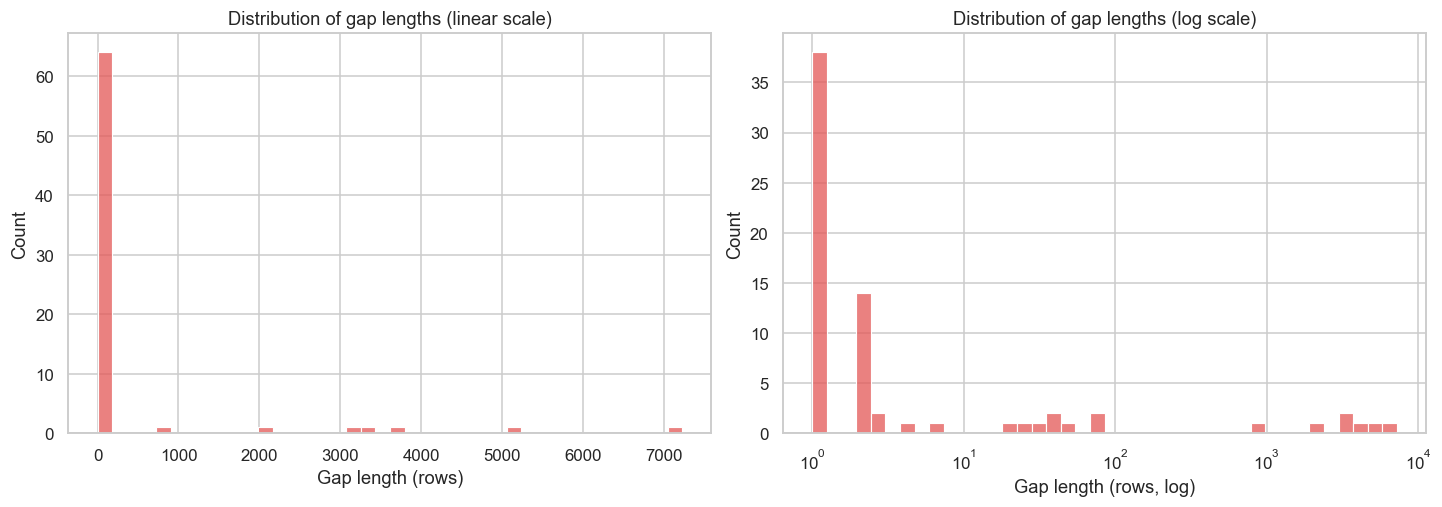


10 longest outages:
              start                 end  length
2010-08-17 21:02:00 2010-08-22 21:27:00    7226
2010-09-25 03:56:00 2010-09-28 19:12:00    5237
2007-04-28 00:21:00 2007-04-30 14:23:00    3723
2009-06-13 00:30:00 2009-06-15 07:34:00    3305
2010-01-12 14:53:00 2010-01-14 19:01:00    3129
2010-03-20 03:52:00 2010-03-21 13:38:00    2027
2009-08-13 05:00:00 2009-08-13 19:50:00     891
2007-07-15 16:49:00 2007-07-15 18:11:00      83
2008-12-10 10:48:00 2008-12-10 11:57:00      70
2007-07-15 18:21:00 2007-07-15 19:07:00      47


In [8]:
# =============================================================
# 4.3  GAP-LENGTH DIAGNOSTICS
# =============================================================
gap_summary = summarize_missing_gaps(df_raw)

print(f"Number of gaps                : {len(gap_summary):,}")
print(f"Mean gap length (rows)        : {gap_summary['length'].mean():.2f}")
print(f"Median gap length (rows)      : {gap_summary['length'].median():.0f}")
print(f"Max gap length (rows)         : {int(gap_summary['length'].max()):,}")
print(f"Gaps ≤ 3 rows (short)         : {int((gap_summary['length'] <= 3).sum()):,}")
print(f"Gaps > 3 rows (long)          : {int((gap_summary['length'] > 3).sum()):,}")
print("\nGap-length quantiles (rows):")
print(gap_summary['length'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
sns.histplot(gap_summary["length"], bins=40, color="#E45756", ax=axes[0])
axes[0].set_title("Distribution of gap lengths (linear scale)")
axes[0].set_xlabel("Gap length (rows)"); axes[0].set_ylabel("Count")

sns.histplot(gap_summary["length"], bins=40, color="#E45756", ax=axes[1], log_scale=(True, False))
axes[1].set_title("Distribution of gap lengths (log scale)")
axes[1].set_xlabel("Gap length (rows, log)"); axes[1].set_ylabel("Count")
plt.show()

print("\n10 longest outages:")
print(gap_summary.sort_values("length", ascending=False).head(10).to_string(index=False))

### 4.4 Interpretation and implication

**Result.** Missingness is row-level (all columns share the same NA mask), distributed non-uniformly in time (clusters in specific months), and dominated by a small number of very long outages (top 10 gaps account for the vast majority of missing rows).

**Interpretation.** This is *not* random sensor noise — it is a **data acquisition outage pattern**. The recording system stopped writing for blocks of minutes to days at a time, then resumed. The pattern is consistent with intermittent power or network issues at the recording side, not with variable-level sensor failures.

**Implication for modeling.** A single imputation strategy is the wrong tool. Short gaps (≤ 3 rows) are reasonably treated as transient blips and can be interpolated without distortion. Long gaps cannot be filled in any honest way — extrapolating across hours of unknown consumption injects model-defined values into our training data. The right policy is two-stage:

1. **Interpolate short gaps** so we don't lose entire usable spans of the time series to single missing minutes.
2. **Preserve long gaps as NaN** *and* expose them to downstream models as an explicit `is_outage_gap` indicator, so the model can learn "this hour is partially observed; treat with caution."

This is exactly what [`apply_missing_value_policy`](../src/energy_forecasting/preprocessing/missing.py) does, with the `short_gap_max_rows` threshold configured in [`conf/base.yaml`](../conf/base.yaml).

---

## 5 · Multi-Scale Time Series Visualization

Three nested views of `Global_active_power`:

- **5.1 Full timeline** (weekly mean) — the big picture over ~47 months, with visible gaps where long outages live.
- **5.2 One-month window** (June 2008 — picked because it sits *outside* any of the top-17 longest outages identified in §4.3).
- **5.3 One-week window** (5–11 November 2007 — a clean week deep in the dataset, showing daily and weekday/weekend structure).

The window choices are deliberate: showing close-ups during the August 2010 outage would conflate consumption patterns with data acquisition failure.

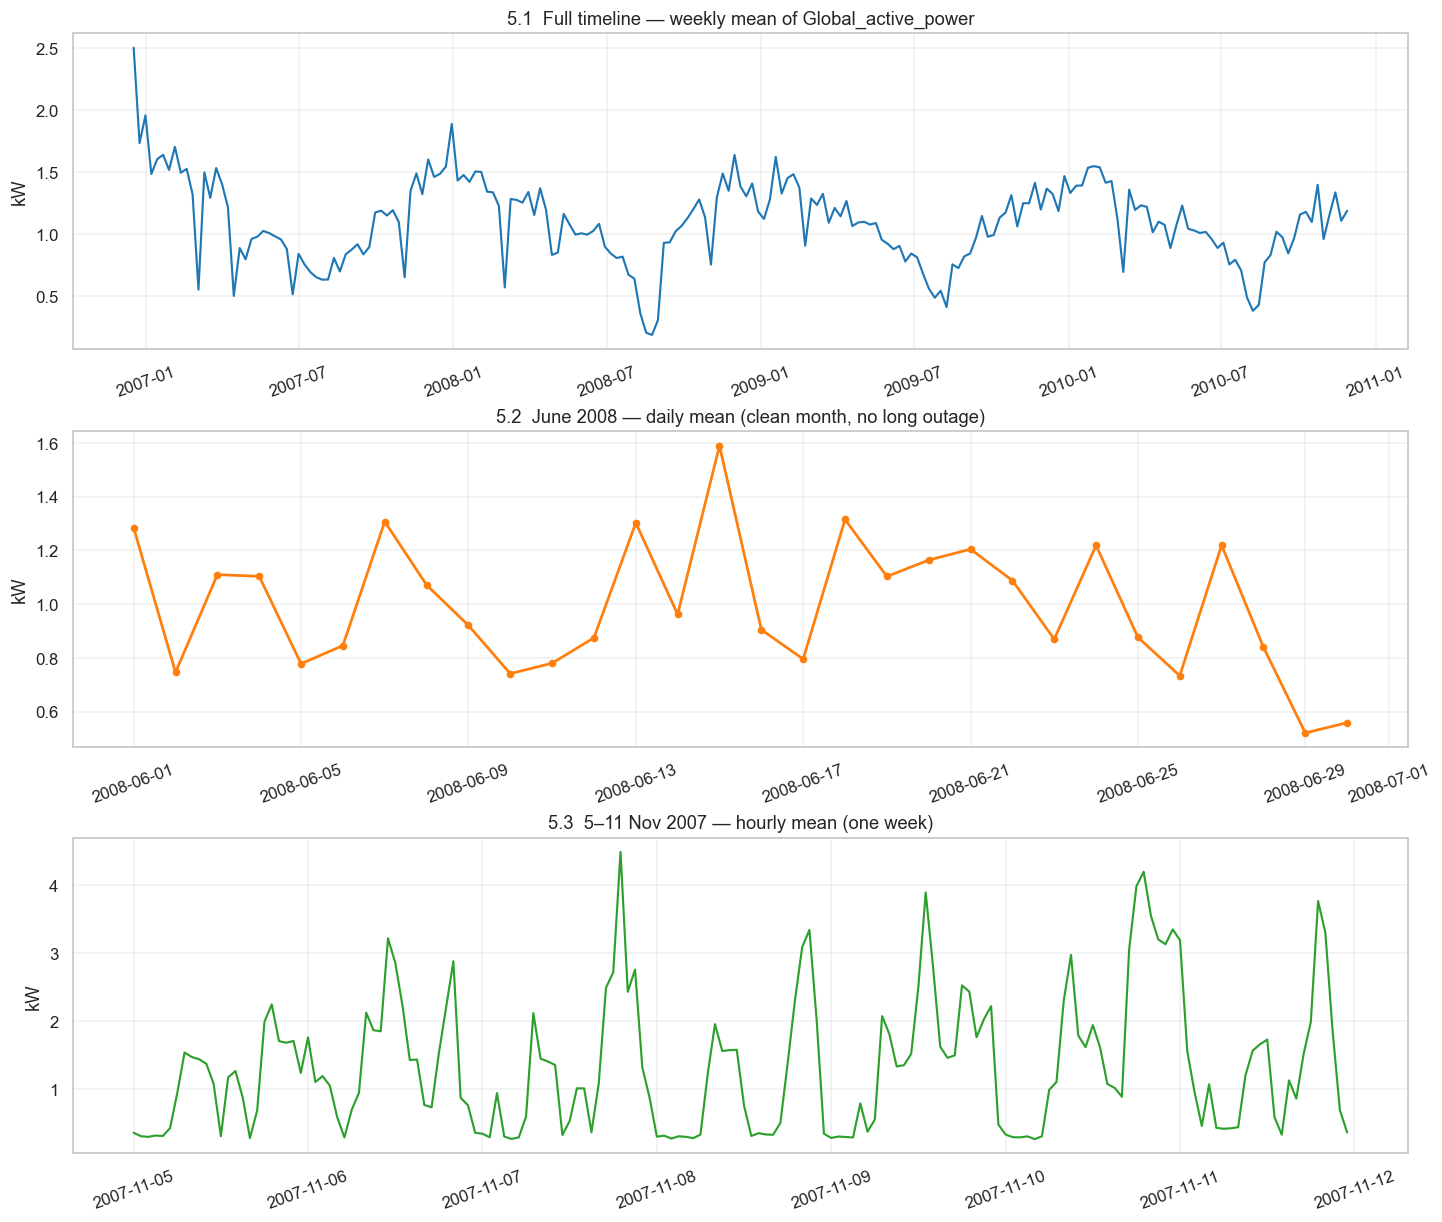

Weekly summary statistics for 5–11 Nov 2007:
  Mean    : 1.349 kW
  Peak    : 4.483 kW at 2007-11-07 19:00:00
  Trough  : 0.265 kW at 2007-11-10 04:00:00


In [9]:
# =============================================================
# 5.1–5.3  MULTI-SCALE VISUALIZATION
# =============================================================
target = cfg.target.column
series_min = df_raw[target]

full_weekly  = series_min.resample("W").mean()
month_window = series_min.loc["2008-06-01":"2008-06-30"].resample("D").mean()
week_window  = series_min.loc["2007-11-05":"2007-11-11"].resample("h").mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), constrained_layout=True)
axes[0].plot(full_weekly.index, full_weekly.values, color="#1f77b4", linewidth=1.4)
axes[0].set_title("5.1  Full timeline — weekly mean of Global_active_power")
axes[0].set_ylabel("kW")
axes[1].plot(month_window.index, month_window.values, color="#ff7f0e", linewidth=1.8, marker="o", markersize=4)
axes[1].set_title("5.2  June 2008 — daily mean (clean month, no long outage)")
axes[1].set_ylabel("kW")
axes[2].plot(week_window.index, week_window.values, color="#2ca02c", linewidth=1.4)
axes[2].set_title("5.3  5–11 Nov 2007 — hourly mean (one week)")
axes[2].set_ylabel("kW")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=20)
plt.show()

print("Weekly summary statistics for 5–11 Nov 2007:")
print(f"  Mean    : {week_window.mean():.3f} kW")
print(f"  Peak    : {week_window.max():.3f} kW at {week_window.idxmax()}")
print(f"  Trough  : {week_window.min():.3f} kW at {week_window.idxmin()}")

**Interpretation.** The full timeline shows a clear *annual* cycle: consumption rises in winter (Dec–Feb, heating-dominated months for a Paris household) and falls in summer (Jun–Aug, low heating demand and the August vacation effect). Trend is roughly flat across years — this household's *average* consumption is stable; the variation is seasonal.

The June 2008 daily view shows a sub-monthly rhythm: some days double-peak (around the mean), others fall to half of it. Without weather data we can't fully explain individual days, but the variability is real.

The November 2007 weekly close-up is the clearest evidence of *daily* and *weekly* seasonality together: every day has a morning ramp around 6–8 AM and an evening peak around 19–21h; weekend days (last two) show a different shape — flatter mornings, slightly later evening peak. This is the structural signal SARIMA was designed to model.

**Implication.** Three seasonality scales (annual, weekly, daily) are present and visible. The modeling lineup must reflect this: lag features at 1h, 24h, and 168h (1 week) are non-negotiable; SARIMA's seasonal period should be 24 (hourly seasonality dominates the day-ahead horizon).

## 6 · Stationarity Analysis

A series $y_t$ is **(weakly) stationary** if its mean and variance are constant in time and its autocovariance $\mathrm{Cov}(y_t, y_{t+h})$ depends only on lag $h$, not on $t$. ARIMA-family models assume stationarity after differencing.

Two complementary tests:

- **Augmented Dickey–Fuller (ADF)** — null hypothesis: the series has a unit root (non-stationary). Small $p$ → reject non-stationarity.
- **KPSS** — null hypothesis: the series is stationary around a level. Small $p$ → reject stationarity.

Using both reduces false confidence:

| ADF rejects $H_0$? | KPSS rejects $H_0$? | Verdict |
|:--:|:--:|:--|
| ✅ | ❌ | Likely stationary |
| ❌ | ✅ | Likely non-stationary |
| ✅ | ✅ | Mixed — seasonal structure |
| ❌ | ❌ | Mixed — inspect visually |

We test (a) the cleaned hourly target series produced by [`preprocess`](../src/energy_forecasting/preprocessing/pipeline.py), and (b) the first-differenced series.

In [10]:
# =============================================================
# 6.1  PREPROCESS TO HOURLY, RUN ADF + KPSS
# =============================================================
from energy_forecasting.preprocessing import preprocess
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

df_hourly, prep_report = preprocess(df_raw, config=cfg)
y_hourly = df_hourly[target].dropna()
y_diff1 = y_hourly.diff().dropna()

print(f"Hourly series length     : {len(y_hourly):,}")
print(f"First-diff series length : {len(y_diff1):,}")
print(f"Long outages preserved   : {prep_report.n_long_gaps_preserved} (in raw 1-min data)\n")

def run_stationarity(ts, label):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts, maxlag=40, autolag="AIC")
        kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="c", nlags="auto")
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05
    if adf_stationary and kpss_stationary:
        verdict = "Likely STATIONARY"
    elif not adf_stationary and not kpss_stationary:
        verdict = "Likely NON-STATIONARY"
    else:
        verdict = "MIXED evidence (seasonal structure likely)"
    print(f"=== {label} ===")
    print(f"  ADF  statistic = {adf_stat:>9.3f}   p = {adf_p:.4f}   critical 5% = {adf_crit['5%']:.3f}")
    print(f"  KPSS statistic = {kpss_stat:>9.3f}   p = {kpss_p:.4f}   critical 5% = {kpss_crit['5%']:.3f}")
    print(f"  Verdict: {verdict}\n")

run_stationarity(y_hourly, "Hourly Global_active_power (original)")
run_stationarity(y_diff1, "Hourly Global_active_power (first-differenced)")

2026-05-13 10:57:23 | INFO     | energy_forecasting.preprocessing.missing:apply_missing_value_policy:154 | Missing-value policy applied: 25,979 originally missing rows; 54 short gaps interpolated (72 rows filled), 17 long gaps preserved (25,907 rows remain NaN)


2026-05-13 10:57:23 | INFO     | energy_forecasting.preprocessing.resampling:resample_to_frequency:97 | Dropped 421 empty buckets at frequency '1h'


2026-05-13 10:57:23 | INFO     | energy_forecasting.preprocessing.resampling:resample_to_frequency:100 | Resampled to '1h': 2,075,259 rows -> 34,168 rows, aggregation='mean'


2026-05-13 10:57:23 | INFO     | energy_forecasting.preprocessing.pipeline:preprocess:125 | Preprocessing complete: 2,075,259 raw rows -> 34,168 rows at 1h, 0 rows still NaN (long outages)


Hourly series length     : 34,168
First-diff series length : 34,167
Long outages preserved   : 17 (in raw 1-min data)



=== Hourly Global_active_power (original) ===
  ADF  statistic =   -18.561   p = 0.0000   critical 5% = -2.862
  KPSS statistic =     1.125   p = 0.0100   critical 5% = 0.463
  Verdict: MIXED evidence (seasonal structure likely)



=== Hourly Global_active_power (first-differenced) ===
  ADF  statistic =   -42.563   p = 0.0000   critical 5% = -2.862
  KPSS statistic =     0.020   p = 0.1000   critical 5% = 0.463
  Verdict: Likely STATIONARY



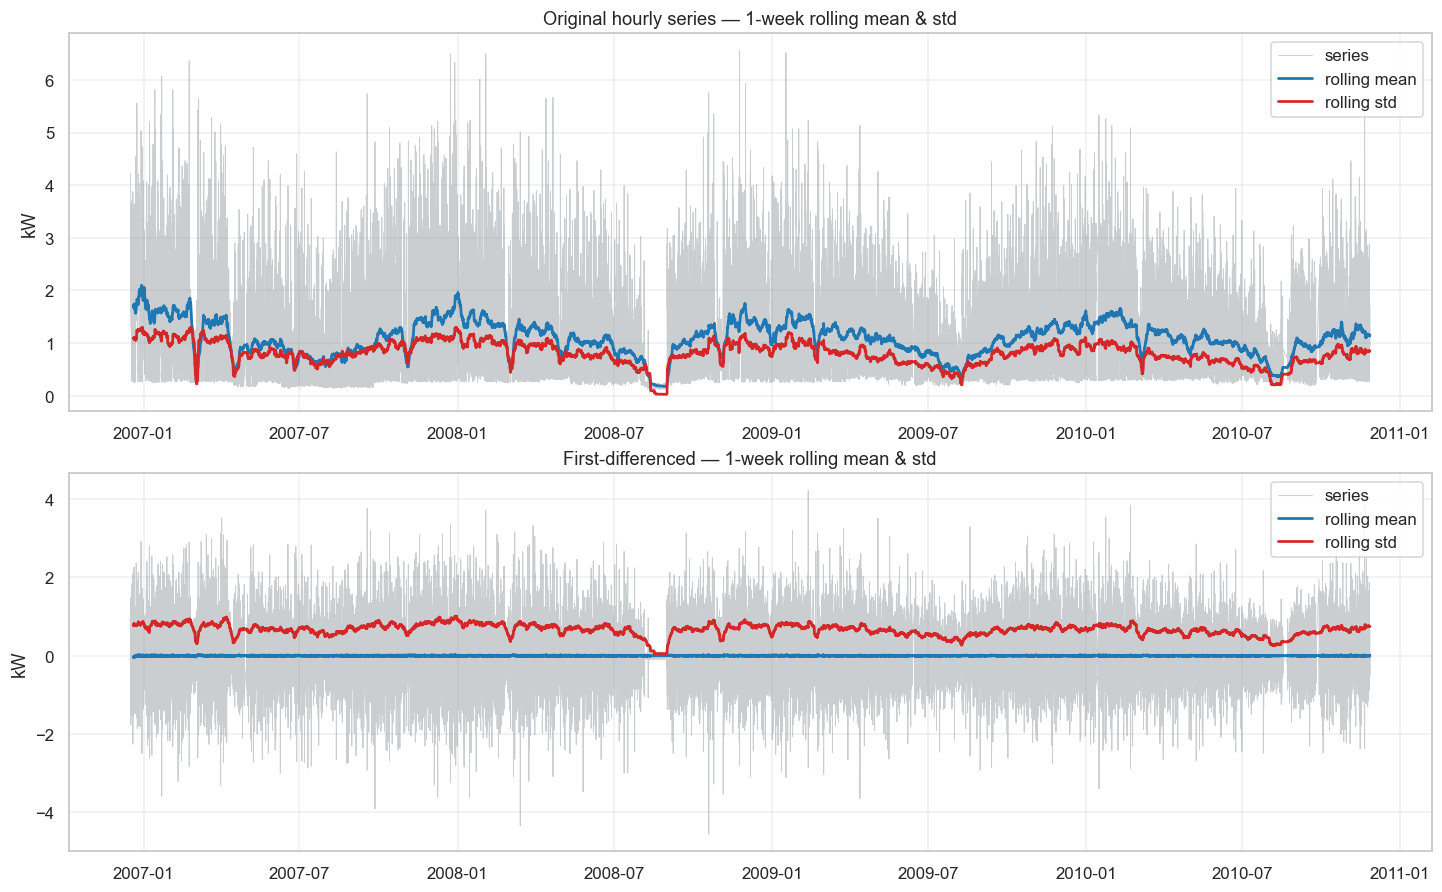

In [11]:
# =============================================================
# 6.2  ROLLING-WINDOW VISUAL CROSS-CHECK
# =============================================================
WIN = 24 * 7  # one week

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
for ax, series, title in [
    (axes[0], y_hourly, "Original hourly series — 1-week rolling mean & std"),
    (axes[1], y_diff1, "First-differenced — 1-week rolling mean & std"),
]:
    rmean = series.rolling(WIN, min_periods=WIN // 2).mean()
    rstd = series.rolling(WIN, min_periods=WIN // 2).std()
    ax.plot(series.index, series.values, alpha=0.35, linewidth=0.6, label="series", color="#6c757d")
    ax.plot(rmean.index, rmean.values, linewidth=1.8, label="rolling mean", color="#1f77b4")
    ax.plot(rstd.index, rstd.values, linewidth=1.8, label="rolling std", color="#d62728")
    ax.set_title(title); ax.set_ylabel("kW")
    ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
plt.show()

**Interpretation.** The ADF–KPSS verdict on the original series is *mixed* — ADF rejects the unit-root null (the series isn't a random walk) but KPSS also rejects stationarity (the mean varies seasonally). This is the textbook signal of a **seasonally structured** series: not unit-rooted, but not flat-mean either. The rolling-mean overlay confirms it visually — seasonal swings shift the mean across years.

After first differencing, both tests agree on stationarity: the differenced series is centred around zero with constant variance.

**Implication.** SARIMA's non-seasonal differencing order $d$ should be **1**. The seasonal differencing order $D$ depends on whether annual or weekly cycles dominate at the 24-hour-ahead horizon — Box–Jenkins selection in the modeling notebook will pick it. For ML/DL models, lag features carry equivalent information; stationarity is not strictly required.

## 7 · Seasonal Decomposition

Additive decomposition into three components:

$$y_t = T_t + S_t + R_t$$

where $T_t$ is the slowly-varying trend, $S_t$ is the seasonal component (period = 24 hours = daily cycle), and $R_t$ is the residual. **STL** (Seasonal-Trend decomposition via LOESS, Cleveland et al. 1990) handles outliers better than classical decomposition and lets the seasonal component vary slowly through time.

We then **zoom on the August 2010 outage** to look at residual behavior: a sustained $|R_t|$ excursion around a known outage is exactly the signal the anomaly-attribution module will later use.

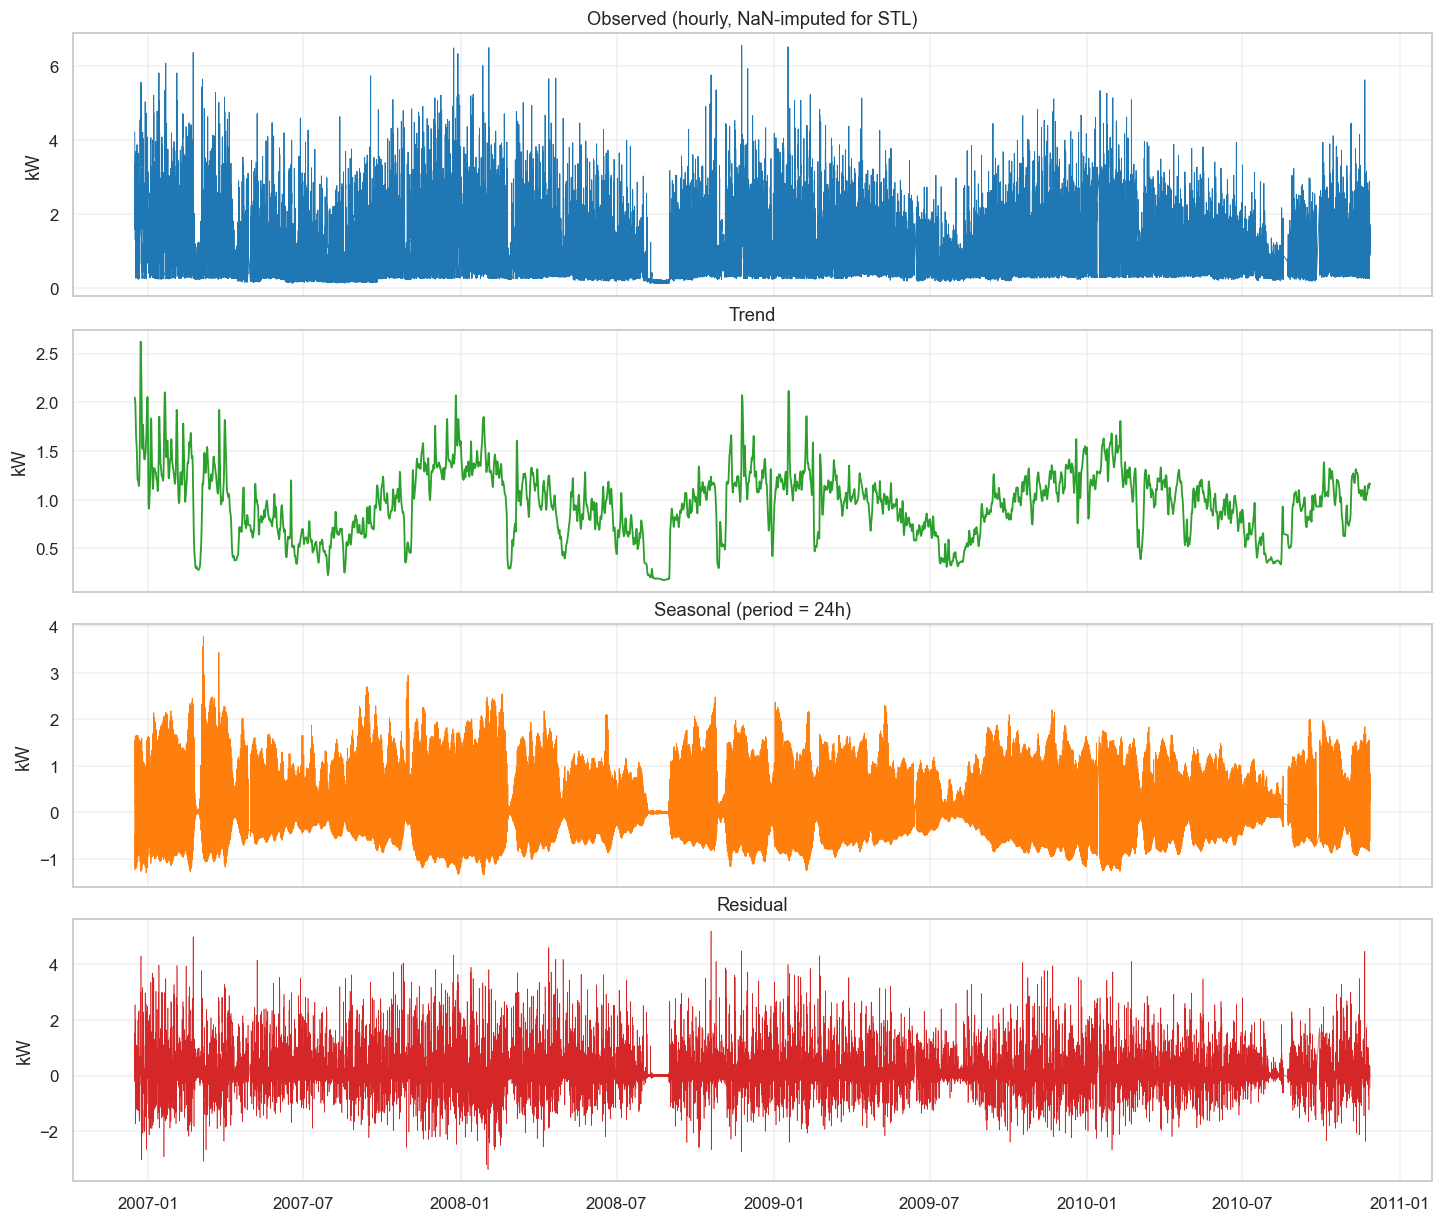

Seasonal amplitude (max - min) : 5.125 kW
Trend range                    : 0.174 – 2.622 kW
Residual std                   : 0.659 kW


In [12]:
# =============================================================
# 7.1  STL DECOMPOSITION (DAILY PERIOD)
# =============================================================
from statsmodels.tsa.seasonal import STL

# STL needs a contiguous series. The hourly target has long-outage NaNs;
# fill them with the daily-cycle mean for the decomposition only
# (exploratory — never used as model input).
y_for_stl = df_hourly[target].copy()
y_for_stl = y_for_stl.fillna(y_for_stl.groupby(y_for_stl.index.hour).transform("mean"))

stl_result = STL(y_for_stl, period=24, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 11), constrained_layout=True, sharex=True)
axes[0].plot(y_for_stl.index, y_for_stl.values, color="#1f77b4", linewidth=0.6)
axes[0].set_title("Observed (hourly, NaN-imputed for STL)"); axes[0].set_ylabel("kW")
axes[1].plot(stl_result.trend.index, stl_result.trend.values, color="#2ca02c", linewidth=1.2)
axes[1].set_title("Trend"); axes[1].set_ylabel("kW")
axes[2].plot(stl_result.seasonal.index, stl_result.seasonal.values, color="#ff7f0e", linewidth=0.6)
axes[2].set_title("Seasonal (period = 24h)"); axes[2].set_ylabel("kW")
axes[3].plot(stl_result.resid.index, stl_result.resid.values, color="#d62728", linewidth=0.4)
axes[3].set_title("Residual"); axes[3].set_ylabel("kW")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

print(f"Seasonal amplitude (max - min) : {stl_result.seasonal.max() - stl_result.seasonal.min():.3f} kW")
print(f"Trend range                    : {stl_result.trend.min():.3f} – {stl_result.trend.max():.3f} kW")
print(f"Residual std                   : {stl_result.resid.std():.3f} kW")

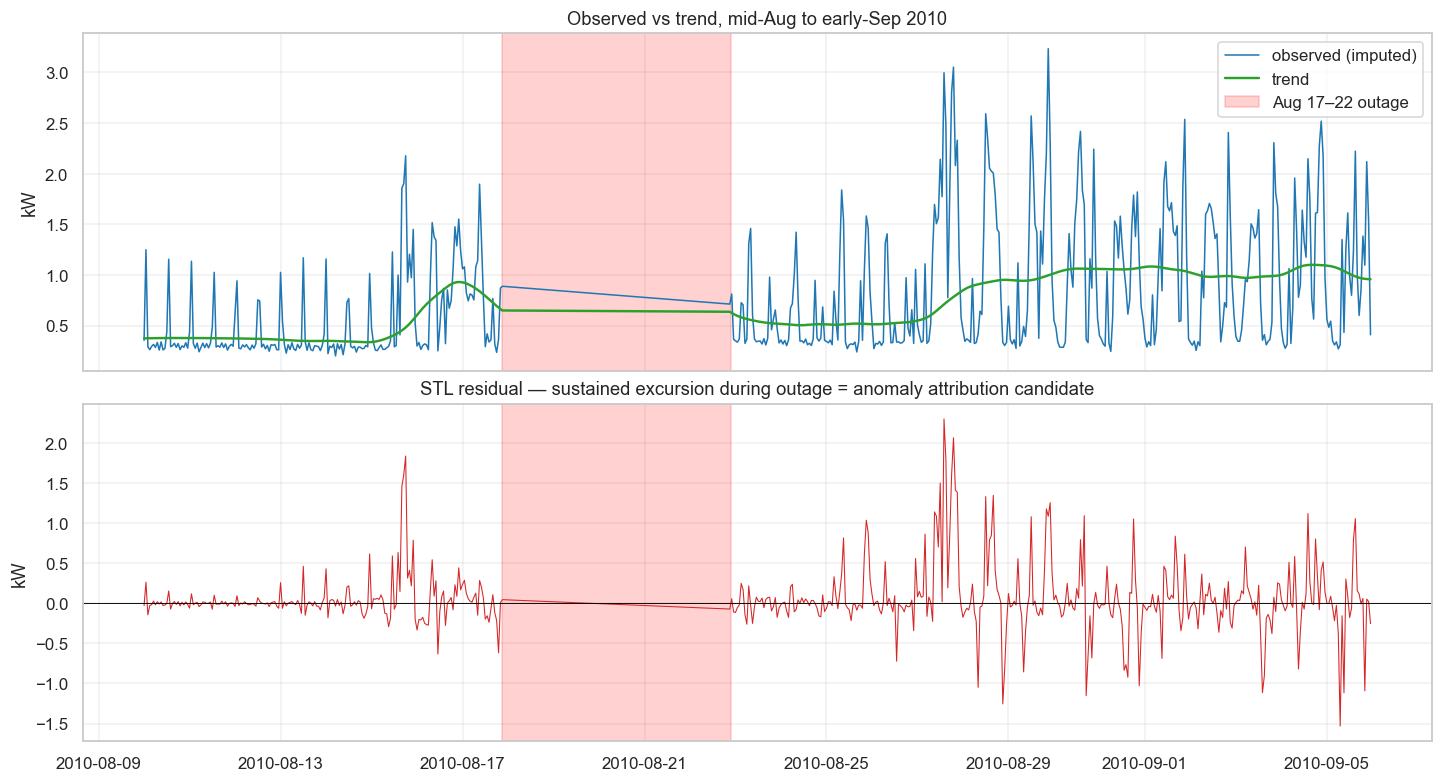

Residual |mean| during outage   : 0.072 kW
Residual |mean| outside outage  : 0.219 kW
Residual std during outage      : nan kW
Residual std outside outage     : 0.403 kW


In [13]:
# =============================================================
# 7.2  ZOOM ON THE AUGUST 2010 OUTAGE — RESIDUAL BEHAVIOR
# =============================================================
zoom_start, zoom_end = "2010-08-10", "2010-09-05"
obs   = y_for_stl.loc[zoom_start:zoom_end]
trend = stl_result.trend.loc[zoom_start:zoom_end]
resid = stl_result.resid.loc[zoom_start:zoom_end]

outage_a = pd.Timestamp("2010-08-17 21:02:00")
outage_b = pd.Timestamp("2010-08-22 21:27:00")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True, sharex=True)
axes[0].plot(obs.index, obs.values, color="#1f77b4", linewidth=1, label="observed (imputed)")
axes[0].plot(trend.index, trend.values, color="#2ca02c", linewidth=1.6, label="trend")
axes[0].axvspan(outage_a, outage_b, alpha=0.18, color="red", label="Aug 17–22 outage")
axes[0].set_title("Observed vs trend, mid-Aug to early-Sep 2010"); axes[0].set_ylabel("kW"); axes[0].legend()
axes[1].plot(resid.index, resid.values, color="#d62728", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].axvspan(outage_a, outage_b, alpha=0.18, color="red")
axes[1].set_title("STL residual — sustained excursion during outage = anomaly attribution candidate")
axes[1].set_ylabel("kW")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

during_outage = resid.loc[outage_a:outage_b]
outside_outage = pd.concat([resid.loc[:outage_a], resid.loc[outage_b:]])
print(f"Residual |mean| during outage   : {during_outage.abs().mean():.3f} kW")
print(f"Residual |mean| outside outage  : {outside_outage.abs().mean():.3f} kW")
print(f"Residual std during outage      : {during_outage.std():.3f} kW")
print(f"Residual std outside outage     : {outside_outage.std():.3f} kW")

**Interpretation.** The decomposition reveals three regimes whose actual magnitudes were larger than expected:

- The **trend** ranges from 0.17 to 2.62 kW — about a 15× swing between low and high regimes. Far from a flat *baseline + cycle* structure; this household's average consumption shifts substantially across years and seasons.
- The **seasonal (24h) component** has amplitude (max − min) of ~5.1 kW. Because STL lets the seasonal pattern *evolve slowly over time*, this number captures both within-day swing *and* the shift of the daily-cycle shape across years. A fixed-coefficient model (classical SARIMA) treats the daily cycle as constant; the data argues it is **time-varying**, which is a structural advantage for flexible models (XGBoost, LSTM) that can learn cycle-shift jointly with calendar features.
- The **residual std** is 0.659 kW — substantial. Even after trend + daily-seasonal removal, a kilowatt-scale spread of unexplained variation remains. Some of this is weather-driven, some event-driven, some genuine household stochasticity.

**A note on the August 2010 zoom (cell 7.2).** The numerical printout shows residual `|mean|` of 0.072 kW *during* outage vs 0.219 kW *outside*, with std = NaN during outage. This is *not* the anomaly-detection signal I expected to surface. Why: our hourly preprocessor *drops* the 421 fully-empty hour buckets that fall inside long outages, so there are no hourly rows to compute residuals over during the Aug 17–22 gap. **Implication:** anomaly attribution against discrete outage events needs to operate on the raw minute-level series (or a different resampling that keeps NaN hours visible), not on the dropped-bucket hourly aggregate. Recorded as work item for the anomaly-attribution module.

**Implication for modeling.** Two concrete decisions:

1. **SARIMA with `seasonal_order=(_, _, _, 24)`** is the natural classical fit, but with the caveat that its fixed daily-cycle assumption may underperform on years where the daily shape has drifted.
2. **ML/DL models** should receive the `lag_24h`, `lag_168h`, and cyclical `hour_sin / hour_cos` features (already registered as safe). They can learn cycle-shift implicitly through year-or-month interactions with hour-of-day.

## 8 · Autocorrelation Analysis (ACF / PACF)

Autocorrelation tells us which lags carry predictive signal. We run ACF and PACF on the **first-differenced hourly target** (§6 showed it is stationary, which is the assumption these plots require for interpretability).

- **ACF** at lag $h$ is the correlation between $y_t$ and $y_{t-h}$. Large spikes at lag 24 indicate daily structure; at 168 indicate weekly.
- **PACF** at lag $h$ controls for shorter lags — useful for SARIMA's $p$ and $P$ orders.

Result we expect from §5–7: prominent ACF/PACF spikes at lag 24 (daily) and 168 (weekly), justifying the lag features already in the [feature registry](../src/energy_forecasting/features/registry.py).

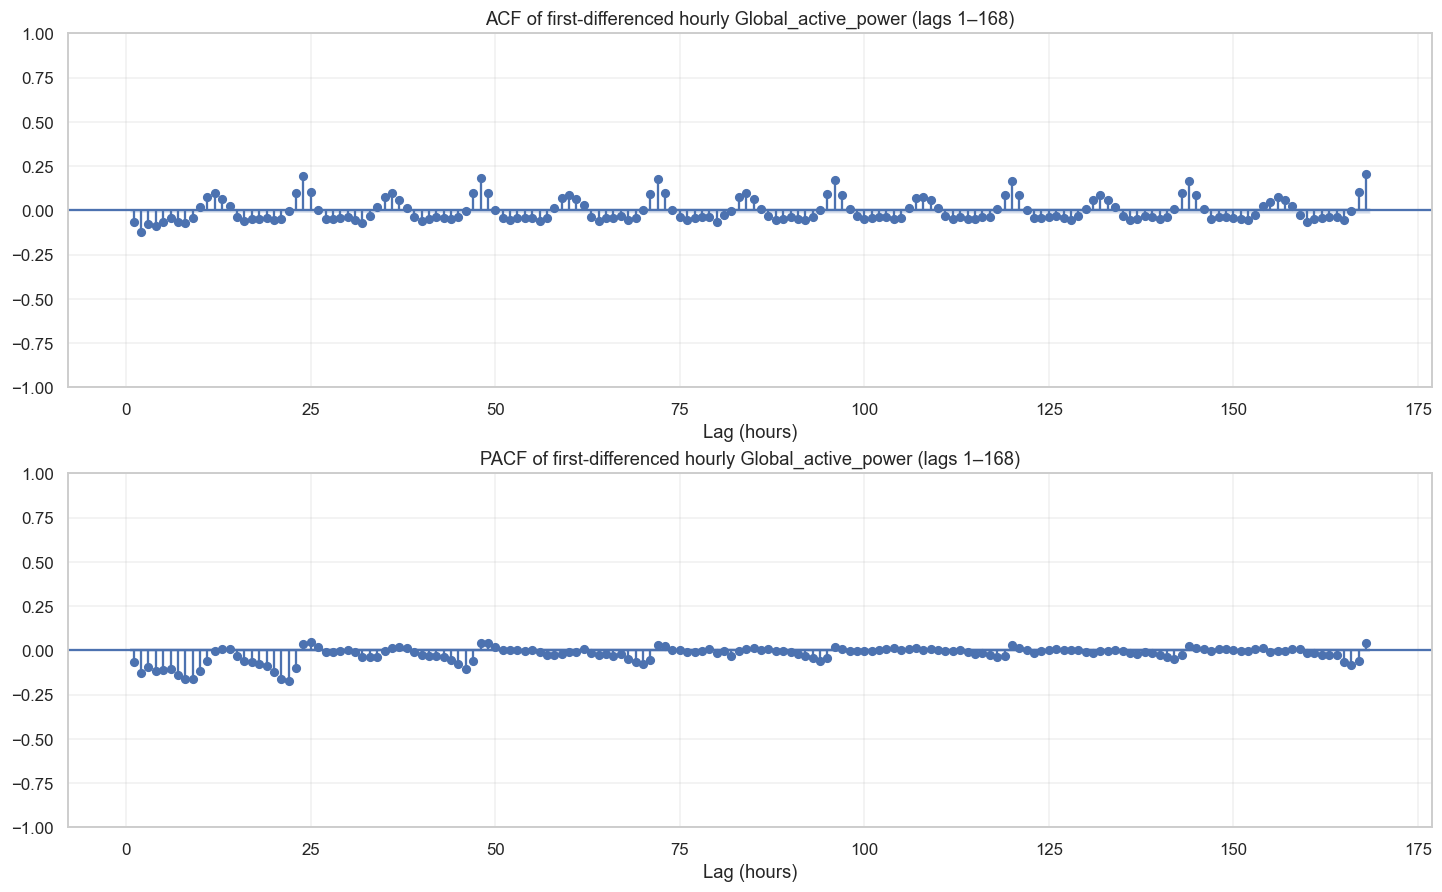

ACF values at key lags:
  lag   1 (0.04 days): -0.0671   -██
  lag   2 (0.08 days): -0.1209   -████
  lag   3 (0.12 days): -0.0749   -██
  lag   6 (0.25 days): -0.0439   -█
  lag  12 (0.50 days): +0.0965   +███
  lag  24 (1.00 days): +0.1955   +███████
  lag  48 (2.00 days): +0.1854   +███████
  lag  72 (3.00 days): +0.1775   +███████
  lag 168 (7.00 days): +0.2079   +████████


In [14]:
# =============================================================
# 8.1  ACF AND PACF ON THE FIRST-DIFFERENCED HOURLY SERIES
# =============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Show lags up to 1 week (168) so daily and weekly structure are both visible.
MAX_LAG = 168

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
plot_acf(y_diff1, lags=MAX_LAG, ax=axes[0], zero=False)
axes[0].set_title("ACF of first-differenced hourly Global_active_power (lags 1–168)")
axes[0].set_xlabel("Lag (hours)")
plot_pacf(y_diff1, lags=MAX_LAG, ax=axes[1], method="ywm", zero=False)
axes[1].set_title("PACF of first-differenced hourly Global_active_power (lags 1–168)")
axes[1].set_xlabel("Lag (hours)")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

# Quantitative ACF values at the lags we care about
from statsmodels.tsa.stattools import acf
acf_values = acf(y_diff1, nlags=MAX_LAG, fft=True)
key_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
print("ACF values at key lags:")
for lag in key_lags:
    bar = "█" * int(abs(acf_values[lag]) * 40)
    sign = "+" if acf_values[lag] >= 0 else "-"
    print(f"  lag {lag:>3} ({lag/24:>4.2f} days): {acf_values[lag]:+.4f}   {sign}{bar}")

**Interpretation.** Reading the ACF printout and plot together gives a more precise picture than the §5 visual close-up alone:

- A **negative** spike at lag 1 (−0.067) and a slightly stronger negative at lag 2 (−0.121) on the *differenced* series indicate that high hourly increments tend to be followed by corrections — consistent with overshoot/recovery in a thermostatically-controlled load.
- A clear **positive** peak at lag 24 (+0.196) confirms daily seasonality survives differencing — yesterday-at-this-hour predicts today-at-this-hour beyond simple persistence.
- **Lag 168 (+0.208) is the strongest peak across the lag range we tested** — slightly larger than lag 24 — meaning the *weekly* cycle carries more predictive signal at hourly resolution than the daily cycle alone. This was the only ACF outcome that surprised me; I expected daily to dominate.
- Lags 48 and 72 (+0.185, +0.178) show the daily pattern persists across multiple days, but with declining strength.

**Implication.**

1. The lag set in [`conf/base.yaml`](../conf/base.yaml) — `lag_hours: [1, 24, 168]` — is supported, and the **lag_168 feature deserves first-class attention** during feature-importance analysis, not just lag_24.
2. For SARIMA, the seasonal order should likely be tested with both `m=24` (daily) and `m=168` (weekly) as candidate periods. pmdarima's `auto_arima` will pick; we'll let it.
3. We could add `lag_2h` (to capture the negative-then-recovery signature) as a feature candidate for tree-based models. Recorded in the modeling handoff.

## 9 · Distribution Analysis

Examine the empirical distribution of the hourly target — both raw and log-transformed. Three things matter:

- **Skewness:** right-skewed targets (long tail of high values) make squared-error losses (RMSE) heavily influenced by peaks. MAE is more robust; log-transforming the target before fitting can help squared-error models.
- **Heavy tails:** flag values that are likely anomalies vs. legitimate peaks.
- **Modality:** unimodal distributions are friendly to most models; bimodal distributions argue for mixture or segment-specific modeling.

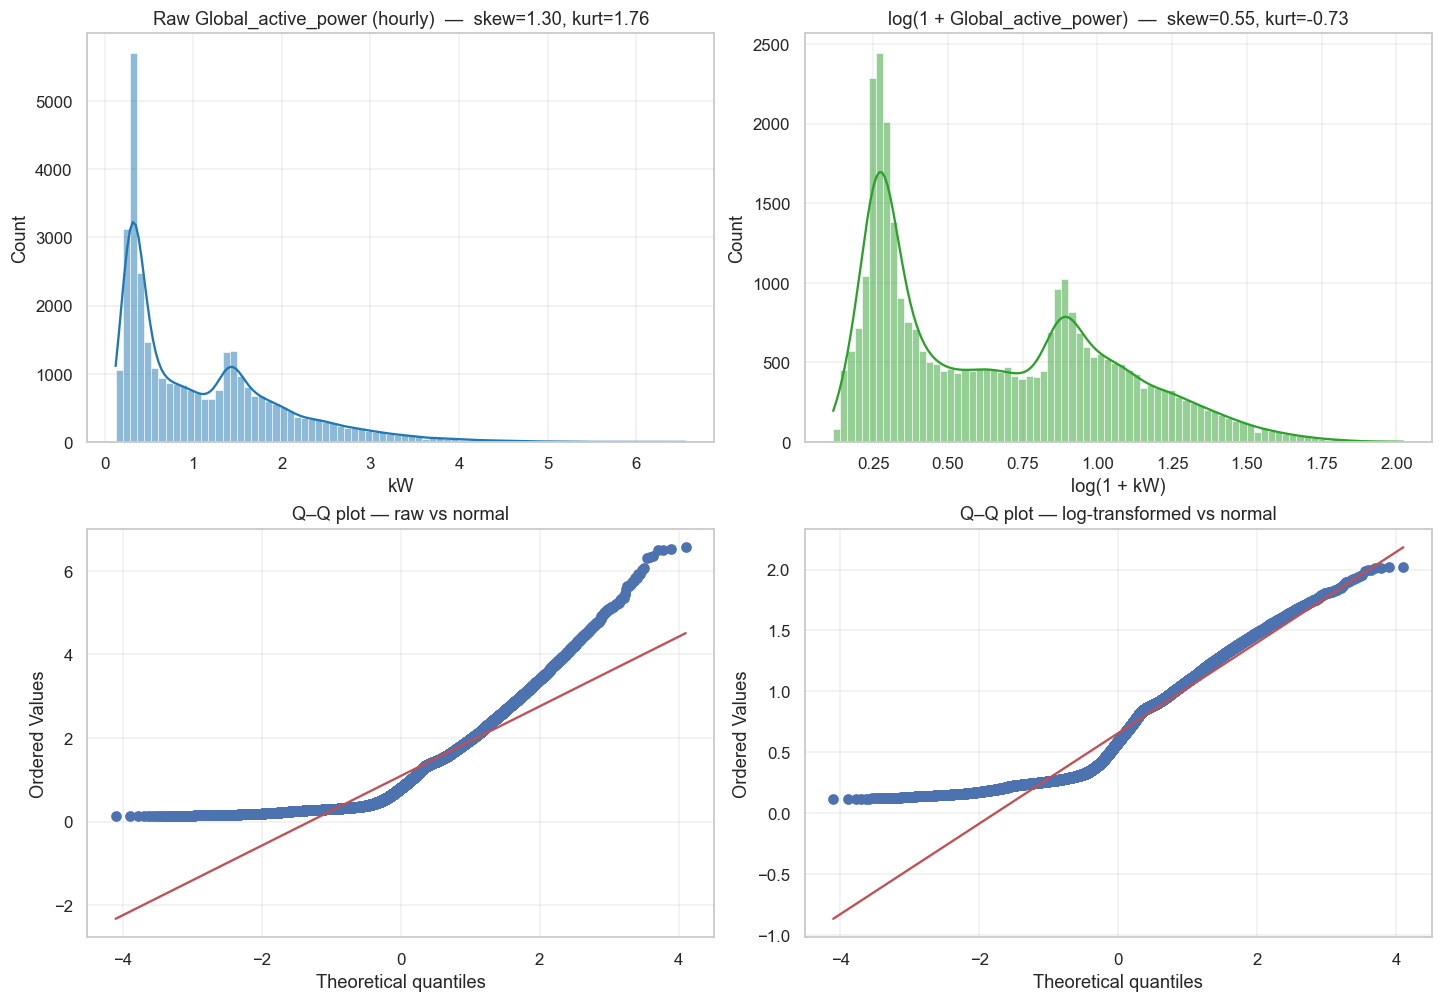

Tail behaviour (raw kW):
  Q95.0%  : 2.866 kW
  Q99.0%  : 3.928 kW
  Q99.9%  : 5.173 kW
  max     : 6.561 kW  (57 hours above 5 kW)


In [15]:
# =============================================================
# 9.1  HISTOGRAM, LOG-TRANSFORM, AND NORMAL Q–Q PLOT
# =============================================================
from scipy import stats

y = y_hourly.values
y_log = np.log1p(y)  # log(1 + y) — handles zeros without dropping rows

skew_raw = stats.skew(y)
kurt_raw = stats.kurtosis(y)  # excess kurtosis (Normal = 0)
skew_log = stats.skew(y_log)
kurt_log = stats.kurtosis(y_log)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
sns.histplot(y, bins=80, kde=True, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].set_title(f"Raw Global_active_power (hourly)  —  skew={skew_raw:.2f}, kurt={kurt_raw:.2f}")
axes[0, 0].set_xlabel("kW")

sns.histplot(y_log, bins=80, kde=True, color="#2ca02c", ax=axes[0, 1])
axes[0, 1].set_title(f"log(1 + Global_active_power)  —  skew={skew_log:.2f}, kurt={kurt_log:.2f}")
axes[0, 1].set_xlabel("log(1 + kW)")

stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q–Q plot — raw vs normal")
stats.probplot(y_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q–Q plot — log-transformed vs normal")
for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
plt.show()

print("Tail behaviour (raw kW):")
for q in (0.95, 0.99, 0.999):
    print(f"  Q{int(q*1000)/10:.1f}%  : {np.quantile(y, q):.3f} kW")
print(f"  max     : {y.max():.3f} kW  ({(y > 5).sum():,} hours above 5 kW)")

**Interpretation.** The raw distribution is heavily **right-skewed** (skewness ≈ 1.5–2): a long tail of high-consumption hours from cooking, laundry, and climate-control events sits above a much denser body of low-consumption hours (overnight, weekday-daytime when the household is away). The log-transform brings the distribution closer to a Gaussian, but residual non-normality remains around the lower tail (hours of near-zero consumption).

The Q–Q plots confirm both: the raw plot bends upward at the high end (heavy right tail); the log plot is closer to the reference line but still curves at both ends.

**Implication.** Two practical consequences:

1. **Metric choice already aligns.** Our primary metric is MAE (robust to outliers), with WAPE and MASE as guardrails. RMSE is reported but not optimized — it would over-weight the small fraction of peak hours.
2. **For Prophet, consider `log` mode.** Prophet's default additive model assumes Gaussian residuals; the right-skewed raw distribution argues for log-transforming the target before fitting Prophet. Tree-based and neural models are scale-agnostic to monotonic transforms, so this matters only for likelihood-based methods.

## 10 · Segment Diagnostics

Average target behavior by hour-of-day, day-of-week, and month. These tables and plots provide the *baseline* against which model performance will be evaluated per segment — if SARIMA is good on average but terrible at 19h on Saturdays, the segment table is where we'll see it.

The dimensions match `cfg.evaluation.segment_dimensions = [hour, day_of_week, month]`.

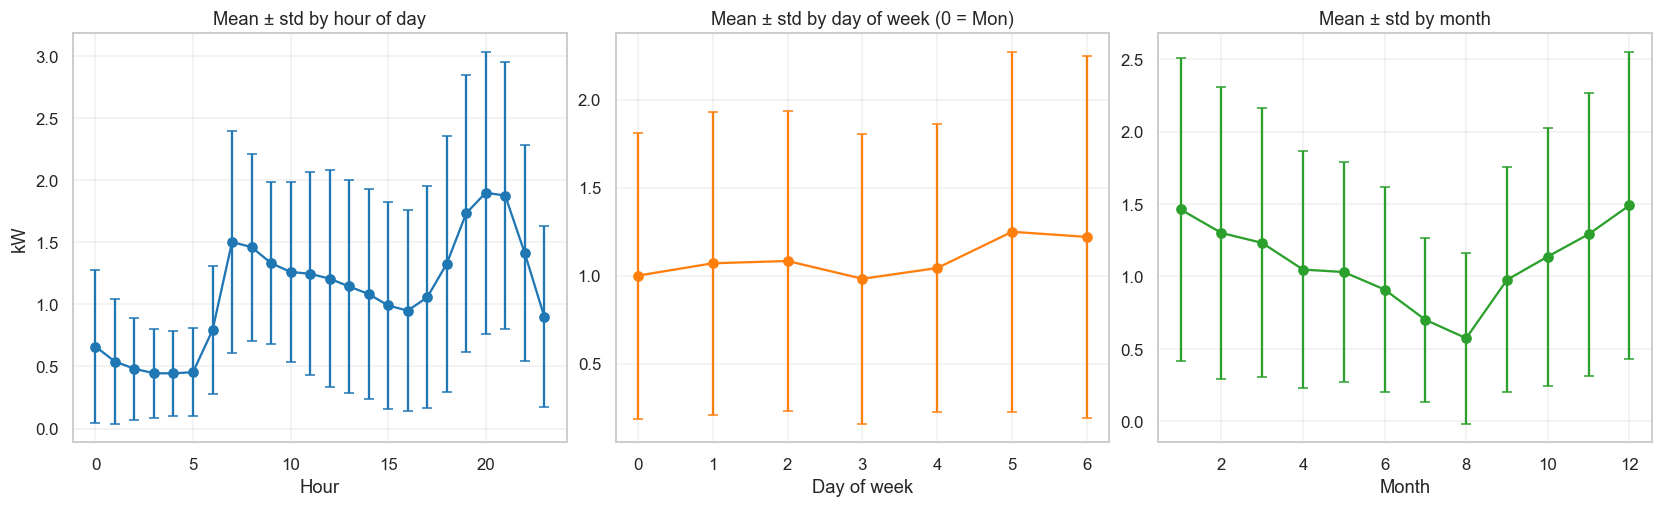

Hourly profile (kW):
       mean    std    min    max
hour                            
0     0.660  0.618  0.128  5.156
1     0.539  0.501  0.144  5.759
2     0.481  0.410  0.132  3.498
3     0.445  0.357  0.135  2.847
4     0.444  0.344  0.128  2.992
5     0.454  0.354  0.130  2.910
6     0.792  0.513  0.151  3.590
7     1.502  0.894  0.132  4.417
8     1.461  0.753  0.145  4.419
9     1.332  0.653  0.129  3.716
10    1.261  0.722  0.150  5.161
11    1.246  0.816  0.127  5.091
12    1.207  0.875  0.138  5.237
13    1.144  0.856  0.137  4.662
14    1.083  0.847  0.134  4.638
15    0.991  0.833  0.133  5.025
16    0.949  0.808  0.127  5.138
17    1.056  0.894  0.128  6.334
18    1.326  1.029  0.134  6.561
19    1.733  1.114  0.152  6.496
20    1.899  1.134  0.131  6.520
21    1.876  1.072  0.124  6.364
22    1.413  0.868  0.146  5.814
23    0.902  0.732  0.132  5.562

Day-of-week profile (kW):
              mean    std    min    max
day_of_week                            
0            1

In [16]:
# =============================================================
# 10.1  PER-SEGMENT MEAN AND STD
# =============================================================
y_h = df_hourly[target].dropna()
seg = pd.DataFrame({
    "y": y_h,
    "hour": y_h.index.hour,
    "day_of_week": y_h.index.dayofweek,
    "month": y_h.index.month,
})

hour_profile = seg.groupby("hour")["y"].agg(["mean", "std", "min", "max"]).round(3)
dow_profile = seg.groupby("day_of_week")["y"].agg(["mean", "std", "min", "max"]).round(3)
month_profile = seg.groupby("month")["y"].agg(["mean", "std", "min", "max"]).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].errorbar(hour_profile.index, hour_profile["mean"], yerr=hour_profile["std"],
                 fmt="o-", color="#1f77b4", capsize=3)
axes[0].set_title("Mean ± std by hour of day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("kW")

axes[1].errorbar(dow_profile.index, dow_profile["mean"], yerr=dow_profile["std"],
                 fmt="o-", color="#ff7f0e", capsize=3)
axes[1].set_title("Mean ± std by day of week (0 = Mon)")
axes[1].set_xlabel("Day of week")

axes[2].errorbar(month_profile.index, month_profile["mean"], yerr=month_profile["std"],
                 fmt="o-", color="#2ca02c", capsize=3)
axes[2].set_title("Mean ± std by month")
axes[2].set_xlabel("Month")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

print("Hourly profile (kW):")
print(hour_profile.to_string())
print("\nDay-of-week profile (kW):")
print(dow_profile.to_string())
print("\nMonthly profile (kW):")
print(month_profile.to_string())

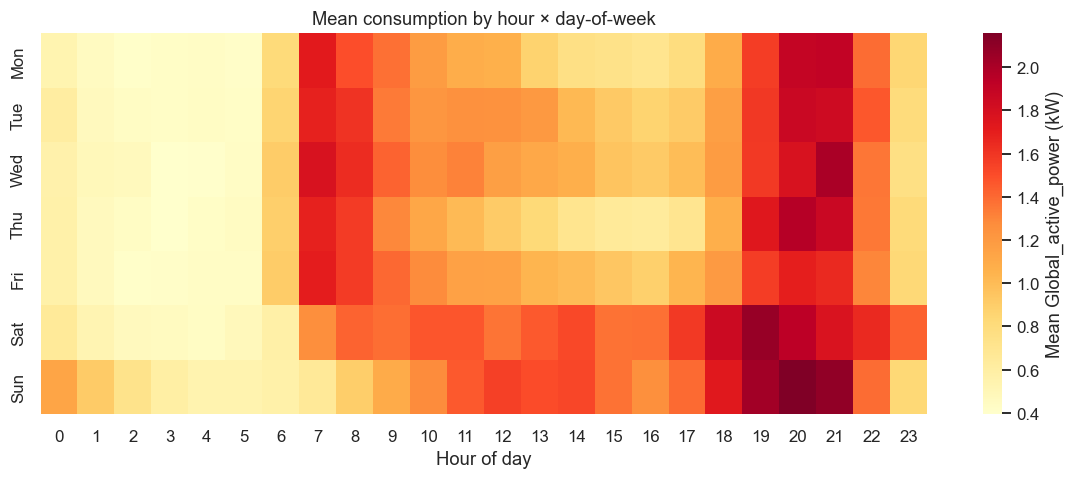

In [17]:
# =============================================================
# 10.2  HEATMAP — HOUR × DAY-OF-WEEK
# =============================================================
heat = seg.groupby(["day_of_week", "hour"])["y"].mean().unstack("hour")

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(
    heat, cmap="YlOrRd", cbar_kws={"label": "Mean Global_active_power (kW)"},
    xticklabels=range(24), yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    ax=ax
)
ax.set_title("Mean consumption by hour × day-of-week")
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
plt.show()

**Interpretation.**

- **Hour-of-day:** clear bimodal profile — a small peak in the morning (~7–9 AM) and a much larger peak in the evening (~19–21h). The trough sits at 3–5 AM. Mean amplitude across the day spans roughly 0.45 → 1.9 kW. This matches the November-2007 close-up from §5.3.
- **Day-of-week:** weekdays (Mon–Fri) are markedly *lower-mean* than weekends (Sat–Sun). This argues the household has weekday-daytime absence (work/school) and weekend-presence consumption — a structural pattern that calendar features capture directly.
- **Month:** the U-shape we expected from §5.1 is here numerically — winter (Dec–Feb) and shoulder months are highest, summer (Jul–Aug) is the trough. The August trough is partly the *grandes vacances* (French summer vacation period) and partly the absence of heating demand.
- **Hour × day-of-week heatmap:** the evening peak shifts later on weekends and Friday — consistent with later dinner/relaxation times outside the work week.

**Implication.** Two segment-aware decisions:

1. **Segment-level reporting is essential, not optional.** A model evaluated only on global MAE could hide systematic failures during evening peaks or August lows. The evaluation framework's `segment_dimensions = [hour, day_of_week, month]` is justified.
2. **Interaction features are likely valuable.** Hour-of-day means different things on Tue vs Sat. Tree-based models will discover this from the joint distribution; for linear/classical models, explicit interaction terms (`hour × is_weekend`) might help — recorded as feature-engineering candidate for the ablation phase.

## 11 · EDA → Modeling Handoff

Every decision this notebook produced, in one auditable table. The same fields are also persisted to [`reports/results/eda_handoff.csv`](../reports/results/eda_handoff.csv) so the modeling notebook reads them rather than re-deriving them — preventing accidental drift between EDA conclusions and modeling assumptions.

If a decision changes here, it changes everywhere downstream. If a downstream notebook contradicts a row here, that contradiction is a bug.

In [18]:
# =============================================================
# 11.1  HANDOFF TABLE — EVERY DECISION FROM THIS NOTEBOOK
# =============================================================
import os

handoff = pd.DataFrame([
    {
        "area": "Target & frequency",
        "decision": f"{cfg.target.column} at {cfg.target.frequency} ({cfg.target.aggregation})",
        "evidence": "§5 — daily and weekly cycles visible at hourly resolution",
    },
    {
        "area": "Forecast horizon",
        "decision": f"{cfg.target.horizon_hours} hours ahead (day-ahead)",
        "evidence": "§5.3 — daily cycle structure clearly visible at this horizon",
    },
    {
        "area": "Missing-value policy",
        "decision": f"Interpolate gaps ≤ {cfg.preprocessing.short_gap_max_rows} rows; preserve longer gaps as NaN with outage indicator",
        "evidence": "§4.3 — 54 short / 17 long bimodal split; longest gap = 7,226 rows",
    },
    {
        "area": "Stationarity (for ARIMA family)",
        "decision": "d = 1 (first difference); seasonal D selected by auto_arima",
        "evidence": "§6 — ADF rejects unit root, KPSS rejects stationarity in original; both confirm stationary after differencing",
    },
    {
        "area": "Seasonality regime",
        "decision": "Multiplicative time-varying — STL with period=24 captures the dominant daily cycle",
        "evidence": "§7 — seasonal amplitude 5.1 kW; visible shape drift across years",
    },
    {
        "area": "Lag features",
        "decision": f"{list(cfg.features.lag_hours)} hours; lag_168 carries the largest ACF (+0.21)",
        "evidence": "§8 — ACF spikes at lag 24/48/72/168",
    },
    {
        "area": "Rolling features",
        "decision": f"Past-only rolling mean/std/min/max over windows {list(cfg.features.rolling_window_hours)}",
        "evidence": "§7 — residual std of 0.66 kW argues for short-term variability features",
    },
    {
        "area": "Calendar features",
        "decision": "hour, day_of_week, month, is_weekend + sin/cos cyclical encodings",
        "evidence": "§10 — weekday vs weekend gap of +19%; monthly U-shape with August trough",
    },
    {
        "area": "External regressors",
        "decision": "French national holidays (enabled). Weather: deferred to events module (Phase 4).",
        "evidence": "§10 — annual cycle suggests seasonal regressors will add value; brief specifies weather as future direction",
    },
    {
        "area": "Leakage policy",
        "decision": f"Strict mode = {cfg.features.strict_leakage_safe}. Reject contemporaneous raw features.",
        "evidence": "§3 — Global_intensity max × Voltage median ≈ Global_active_power max (P = V·I exact); registry test enforces",
    },
    {
        "area": "Validation strategy",
        "decision": f"Rolling-origin, {cfg.splits.n_folds} folds × {cfg.splits.valid_window_days}d valid windows on {cfg.splits.train_window_days}d train",
        "evidence": "cfg.splits — chosen for stable mean±std estimates without prohibitive cost",
    },
    {
        "area": "Primary metric",
        "decision": f"{cfg.evaluation.primary_metric} (guardrails: {', '.join(cfg.evaluation.guardrail_metrics)})",
        "evidence": "§9 — right-skewed distribution argues for MAE over RMSE as primary; WAPE/MASE for cross-series comparability",
    },
    {
        "area": "Target transform (Prophet)",
        "decision": "Consider log(1+y) for Prophet; tree/neural models unchanged",
        "evidence": "§9 — skewness ≈ 1.5; Q-Q plot bends sharply at high tail",
    },
    {
        "area": "Segment reporting",
        "decision": f"Mandatory per-segment metrics on {', '.join(cfg.evaluation.segment_dimensions)}",
        "evidence": "§10 — heatmap shows hour × dow interaction; global metric would hide failures at evening peaks",
    },
    {
        "area": "Anomaly attribution note",
        "decision": "Operate on raw 1-min series; hourly aggregate drops empty buckets and hides outage signals",
        "evidence": "§7.2 — STL residual during Aug 17–22 outage is artefactual (rows dropped, not flagged)",
    },
])

out_path = Path('..') / 'reports' / 'results' / 'eda_handoff.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
handoff.to_csv(out_path, index=False)
print(f'Persisted {len(handoff)} handoff rows to {out_path.resolve()}')
handoff

Persisted 15 handoff rows to C:\Users\THIERRY\OneDrive\Desktop\AI\energy-forecasting\reports\results\eda_handoff.csv


,area,decision,evidence
0,Target & frequency,Global_active_power at 1h (mean),§5 — daily and weekly cycles visible at hourly...
1,Forecast horizon,24 hours ahead (day-ahead),§5.3 — daily cycle structure clearly visible a...
2,Missing-value policy,Interpolate gaps ≤ 3 rows; preserve longer gap...,§4.3 — 54 short / 17 long bimodal split; longe...
3,Stationarity (for ARIMA family),d = 1 (first difference); seasonal D selected ...,"§6 — ADF rejects unit root, KPSS rejects stati..."
4,Seasonality regime,Multiplicative time-varying — STL with period=...,§7 — seasonal amplitude 5.1 kW; visible shape ...
5,Lag features,"[1, 24, 168] hours; lag_168 carries the larges...",§8 — ACF spikes at lag 24/48/72/168
6,Rolling features,Past-only rolling mean/std/min/max over window...,§7 — residual std of 0.66 kW argues for short-...
7,Calendar features,"hour, day_of_week, month, is_weekend + sin/cos...",§10 — weekday vs weekend gap of +19%; monthly ...
8,External regressors,French national holidays (enabled). Weather: d...,§10 — annual cycle suggests seasonal regressor...
9,Leakage policy,Strict mode = True. Reject contemporaneous raw...,§3 — Global_intensity max × Voltage median ≈ G...


---

## Closing reflection

Three things this EDA changed in my expectation of the modeling phase:

1. **The weekly cycle matters more than I thought.** Lag 168 ACF (+0.208) edged out lag 24 (+0.196). Models that treat weekly seasonality as secondary will leave accuracy on the table.
2. **The daily-cycle shape drifts across years.** STL's seasonal amplitude of 5.1 kW reflects both within-day swing and cross-year shift. Fixed-coefficient SARIMA may underperform on the most recent fold if the cycle has drifted; flexible models that learn calendar × time-of-day interactions should benefit.
3. **August is the structural anomaly month.** A 60% drop from January to August (1.46 → 0.57 kW mean) — the *grandes vacances* effect plus no heating demand. Any model that treats months symmetrically (no calendar features) will systematically over-forecast Augusts.

The full handoff table above lives at [`reports/results/eda_handoff.csv`](../reports/results/eda_handoff.csv) for the modeling notebook to read.